# 1MTR58 – LAB2 – Experiencia 2
## Procesamiento y caracterización de señales EOG

En esta parte se trabajará con las señales EOG del **sujeto S1**.

El flujo llega hasta construir un `features_df` a partir de ventanas de señal y realizar una comparación de características entre clases.

**Carga → exploración → EOGh/EOGv → preprocesamiento → segmentación → ventaneo → características**

El entrenamiento del modelo se realizará posteriormente con los datos de los siete sujetos.


## Verificación del entorno

Ejecute esta celda antes de comenzar. Si falta alguna librería, el notebook intentará instalarla automáticamente en el mismo entorno de Python que está utilizando.

Si se instala alguna dependencia, reinicie el kernel y vuelva a ejecutar el notebook desde el inicio.


In [7]:
import sys
import subprocess
import importlib.util

packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
}

missing = [
    package
    for module, package in packages.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Faltan librerías:", missing)
    print("Instalando en el entorno actual...")

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *missing]
    )

    print("\nInstalación completada.")
    print("Reinicie el kernel y vuelva a ejecutar desde el inicio.")
else:
    print("✓ Todas las librerías necesarias están instaladas.")


✓ Todas las librerías necesarias están instaladas.


## 0. Configuración

Para esta parte del laboratorio se utilizarán:

- `S1-EOG.csv`
- `S1-ControlSignal.csv`


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

DATA_DIR = Path("data")
FS = 256

EOG_PATH = DATA_DIR / "S1-EOG.csv"
CS_PATH = DATA_DIR / "S1-ControlSignal.csv"

print("EOG:", EOG_PATH)
print("ControlSignal:", CS_PATH)


EOG: data\S1-EOG.csv
ControlSignal: data\S1-ControlSignal.csv


## 1. Análisis exploratorio

Revisar las señales V1, V2, V3 y V4 y realizar el análisis exploratorio correspondiente.


In [11]:
df_eog = pd.read_csv(EOG_PATH)
df_cs = pd.read_csv(CS_PATH)

# Eliminar columnas de índice exportadas por error
df_eog = df_eog.loc[:, ~df_eog.columns.str.contains(r"^Unnamed")].copy()
df_cs = df_cs.loc[:, ~df_cs.columns.str.contains(r"^Unnamed")].copy()

df_eog.columns = [c.strip() for c in df_eog.columns]
df_cs.columns = [c.strip() for c in df_cs.columns]

if "ControlSignal" not in df_cs.columns:
    if len(df_cs.columns) == 1:
        df_cs.columns = ["ControlSignal"]
    else:
        raise ValueError("No se encontró la columna ControlSignal.")

required = {"V1", "V2", "V3", "V4"}
missing = required - set(df_eog.columns)
if missing:
    raise ValueError(f"Faltan columnas EOG: {sorted(missing)}")

print("Dimensión EOG:", df_eog.shape)
print("Dimensión ControlSignal:", df_cs.shape)
print("\nTipos:")
print(df_eog.dtypes)
print("\nNaN:")
print(df_eog.isna().sum())
print("\nEstadísticas:")
display(df_eog[["V1","V2","V3","V4"]].describe())


Dimensión EOG: (312339, 4)
Dimensión ControlSignal: (312338, 1)

Tipos:
V1    float64
V2    float64
V3    float64
V4    float64
dtype: object

NaN:
V1    0
V2    0
V3    0
V4    0
dtype: int64

Estadísticas:


,V1,V2,V3,V4
count,312339.000000,312339.000000,312339.000000,312339.000000
mean,-2460.335236,2482.371011,267.302010,-187.268470
std,563.725829,563.730411,169.278374,169.264554
min,-3013.369141,-352.456055,-316.495605,-715.670410
25%,-2824.054199,2372.386230,130.884766,-311.466309
50%,-2668.952148,2691.100586,292.971680,-212.869141
75%,-2350.389648,2845.990234,391.742920,-50.997803
max,371.629395,3034.144531,799.119629,396.804688


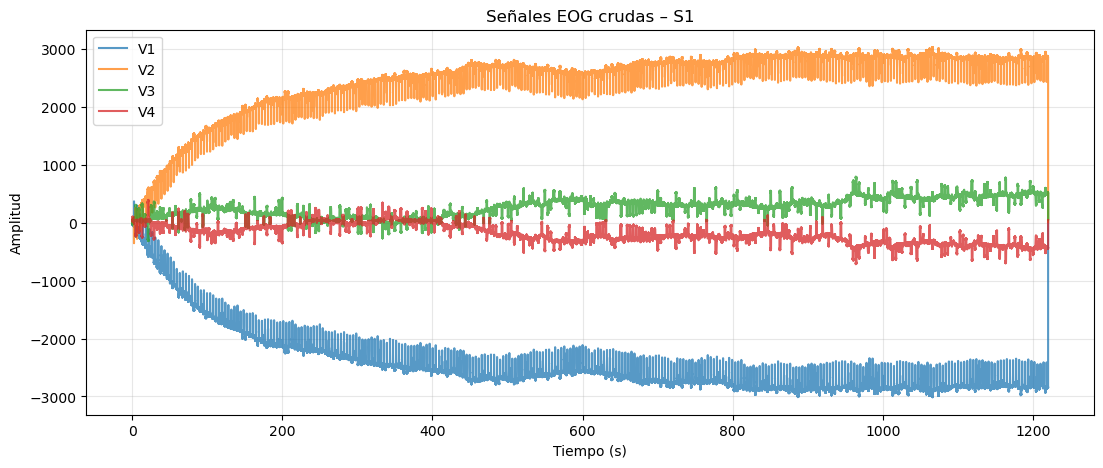

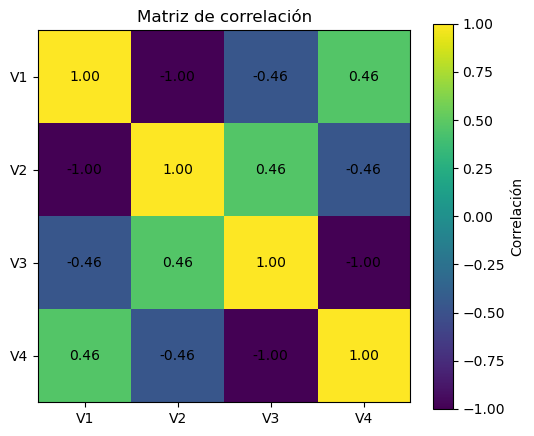

In [12]:
# Visualización de V1–V4
time_eog = np.arange(len(df_eog)) / FS

fig, ax = plt.subplots(figsize=(13,5))
for col in ["V1","V2","V3","V4"]:
    ax.plot(time_eog, df_eog[col], label=col, alpha=0.75)
ax.set_title(f"Señales EOG crudas – S1")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Matriz de correlación sin seaborn
corr = df_eog[["V1","V2","V3","V4"]].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(4), corr.columns)
ax.set_yticks(range(4), corr.index)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Correlación")
ax.set_title("Matriz de correlación")
plt.show()


## 2. Construcción de EOGh y EOGv

Integrar la señal EOG con `ControlSignal` y construir las señales horizontal y vertical.


In [14]:
n = min(len(df_eog), len(df_cs))
df = pd.concat(
    [
        df_eog.iloc[:n].reset_index(drop=True),
        df_cs[["ControlSignal"]].iloc[:n].reset_index(drop=True),
    ],
    axis=1,
)

df["subject_id"] = "S1"
df["Tiempo"] = np.arange(len(df)) / FS

df["EOGh"] = df["V3"] - df["V4"]
df["EOGv"] = df["V1"] - df["V2"]

print("DataFrame integrado:", df.shape)
print("\nClases:")
print(df["ControlSignal"].value_counts().sort_index())
display(df.head())


DataFrame integrado: (312338, 9)

Clases:
ControlSignal
1      78078
2      77866
3     156393
30         1
Name: count, dtype: int64


,V1,V2,V3,V4,ControlSignal,subject_id,Tiempo,EOGh,EOGv
0,14.500000,13.500000,44.000000,44.000000,1,S1,0.000000,0.000000,1.000000
1,20.000000,20.000000,34.000000,34.000000,1,S1,0.003906,0.000000,0.000000
2,15.877930,16.122070,50.601562,49.398438,1,S1,0.007812,1.203125,-0.244141
3,13.945312,14.054688,41.209961,38.790039,1,S1,0.011719,2.419922,-0.109375
4,12.261719,11.738281,35.775391,32.224609,1,S1,0.015625,3.550781,0.523438


## 3. Preprocesamiento

Procesar las señales EOGh y EOGv y comparar el resultado con las señales originales.

Las decisiones tomadas en esta etapa deben poder justificarse a partir del comportamiento observado en las señales.


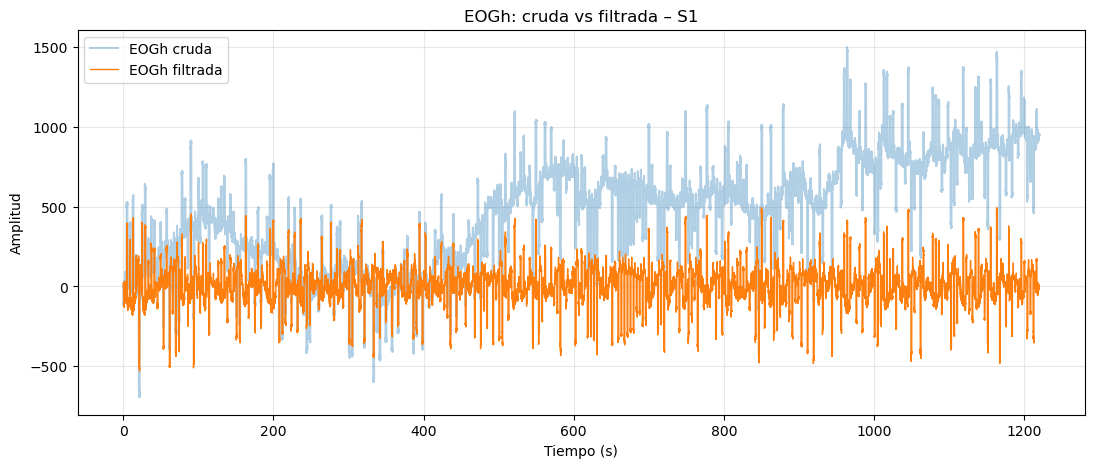

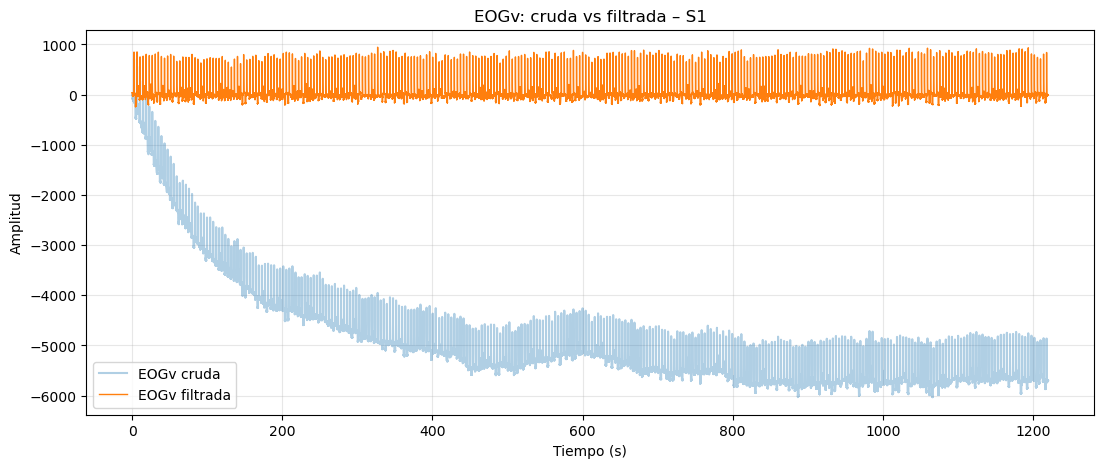

In [15]:
def bandpass_filter(x, fs=256, lowcut=0.1, highcut=30.0, order=4):
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype="band")
    return filtfilt(b, a, x)

df["EOGh_filt"] = bandpass_filter(df["EOGh"], fs=FS)
df["EOGv_filt"] = bandpass_filter(df["EOGv"], fs=FS)

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df["Tiempo"], df["EOGh"], label="EOGh cruda", alpha=0.35)
ax.plot(df["Tiempo"], df["EOGh_filt"], label="EOGh filtrada", linewidth=1)
ax.set_title(f"EOGh: cruda vs filtrada – S1")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(df["Tiempo"], df["EOGv"], label="EOGv cruda", alpha=0.35)
ax.plot(df["Tiempo"], df["EOGv_filt"], label="EOGv filtrada", linewidth=1)
ax.set_title(f"EOGv: cruda vs filtrada – S1")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## 4. Segmentación

Separar primero los bloques continuos de cada clase antes de realizar el ventaneo.


In [16]:
df["block_id"] = (df["ControlSignal"] != df["ControlSignal"].shift()).cumsum()

segments = (
    df.groupby("block_id")
      .agg(
          label=("ControlSignal", "first"),
          start_idx=("ControlSignal", lambda x: x.index[0]),
          end_idx=("ControlSignal", lambda x: x.index[-1]),
          n_samples=("ControlSignal", "size"),
          start_time=("Tiempo", "first"),
          end_time=("Tiempo", "last"),
      )
      .reset_index(drop=True)
)

segments["duration_s"] = segments["n_samples"] / FS

print("Número total de segmentos:", len(segments))
print("\nSegmentos por clase:")
print(segments["label"].value_counts().sort_index())
display(segments.head(10))


Número total de segmentos: 901

Segmentos por clase:
label
1     300
2     300
3     300
30      1
Name: count, dtype: int64


,label,start_idx,end_idx,n_samples,start_time,end_time,duration_s
0,1,0,266,267,0.000000,1.039062,1.042969
1,2,267,530,264,1.042969,2.070312,1.031250
2,3,531,1040,510,2.074219,4.062500,1.992188
3,1,1041,1305,265,4.066406,5.097656,1.035156
4,2,1306,1569,264,5.101562,6.128906,1.031250
5,3,1570,2079,510,6.132812,8.121094,1.992188
6,1,2080,2343,264,8.125000,9.152344,1.031250
7,2,2344,2607,264,9.156250,10.183594,1.031250
8,3,2608,3137,530,10.187500,12.253906,2.070312
9,1,3138,3380,243,12.257812,13.203125,0.949219


## 5. Ventaneo

Definir el tamaño de ventana y el overlap que se utilizarán.

Estos parámetros forman parte del análisis del grupo, por lo que deben ser seleccionados y justificados antes de continuar.


In [17]:
# Defina los parámetros de ventaneo antes de ejecutar esta celda.
WINDOW_SEC = 1    # tamaño de ventana en segundos
OVERLAP = 0.5      # fracción de overlap: valor entre 0 y 1

if WINDOW_SEC is None or OVERLAP is None:
    raise ValueError("Defina WINDOW_SEC y OVERLAP antes de continuar.")

if WINDOW_SEC <= 0:
    raise ValueError("WINDOW_SEC debe ser mayor que 0.")

if not (0 <= OVERLAP < 1):
    raise ValueError("OVERLAP debe estar entre 0 y 1.")

WIN_SIZE = int(WINDOW_SEC * FS)
STEP = int(WIN_SIZE * (1 - OVERLAP))

if WIN_SIZE <= 0 or STEP <= 0:
    raise ValueError("Revise los parámetros de ventaneo.")

records = []

for _, seg in segments.iterrows():
    label = int(seg["label"])
    start_seg = int(seg["start_idx"])
    end_seg = int(seg["end_idx"]) + 1

    if end_seg - start_seg < WIN_SIZE:
        continue

    for start in range(start_seg, end_seg - WIN_SIZE + 1, STEP):
        end = start + WIN_SIZE

        # Cada ventana debe pertenecer a una sola clase.
        if df.loc[start:end-1, "ControlSignal"].nunique() != 1:
            continue

        records.append({
            "subject_id": "S1",
            "label": label,
            "start_idx": start,
            "end_idx": end - 1,
            "EOGh_window": df.loc[start:end-1, "EOGh_filt"].to_numpy(),
            "EOGv_window": df.loc[start:end-1, "EOGv_filt"].to_numpy(),
        })

windows_df = pd.DataFrame(records)

print("Tamaño de ventana (muestras):", WIN_SIZE)
print("Overlap (%):", OVERLAP * 100)
print("Total de ventanas:", len(windows_df))
print("\nVentanas por clase:")
print(windows_df["label"].value_counts().sort_index())

display(windows_df[["subject_id", "label", "start_idx", "end_idx"]].head())


Tamaño de ventana (muestras): 256
Overlap (%): 50.0
Total de ventanas: 1246

Ventanas por clase:
label
1    243
2    240
3    763
Name: count, dtype: int64


,subject_id,label,start_idx,end_idx
0,S1,1,0,255
1,S1,2,267,522
2,S1,3,531,786
3,S1,3,659,914
4,S1,1,1041,1296


## 6. Extracción de características

Seleccionar y calcular las características que se consideren adecuadas para representar cada ventana de EOGh y EOGv.

Al finalizar esta sección debe obtenerse un `features_df` con una fila por ventana.


In [18]:
def extract_features(x, prefix):
    x = np.asarray(x, dtype=float)

    features = {
        f"{prefix}_mean": np.mean(x),
        f"{prefix}_mav": np.mean(np.abs(x)),
        f"{prefix}_rms": np.sqrt(np.mean(x**2)),
        f"{prefix}_std": np.std(x),
        f"{prefix}_max": np.max(x),
        f"{prefix}_min": np.min(x),
        f"{prefix}_ptp": np.ptp(x),
        f"{prefix}_wl": np.sum(np.abs(np.diff(x))),
    }

    return features

feature_rows = []

for _, row in windows_df.iterrows():
    feats = {}

    feats.update(extract_features(row["EOGh_window"], "EOGh"))
    feats.update(extract_features(row["EOGv_window"], "EOGv"))

    feats["subject_id"] = row["subject_id"]
    feats["label"] = row["label"]
    feats["start_idx"] = row["start_idx"]
    feats["end_idx"] = row["end_idx"]

    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)

feature_cols = [
    c for c in features_df.columns
    if c not in {"subject_id", "label", "start_idx", "end_idx"}
]

if len(feature_cols) == 0:
    raise ValueError(
        "Implemente las características seleccionadas en extract_features() antes de continuar."
    )

print("Tamaño del dataframe final:", features_df.shape)
print("\nVentanas por clase:")
print(features_df["label"].value_counts().sort_index())

display(features_df.head())


Tamaño del dataframe final: (1246, 20)

Ventanas por clase:
label
1    243
2    240
3    763
Name: count, dtype: int64


,EOGh_mean,EOGh_mav,EOGh_rms,EOGh_std,EOGh_max,EOGh_min,EOGh_ptp,EOGh_wl,EOGv_mean,EOGv_mav,EOGv_rms,EOGv_std,EOGv_max,EOGv_min,EOGv_ptp,EOGv_wl,subject_id,label,start_idx,end_idx
0,-69.180199,78.183370,87.740835,53.968085,23.088291,-113.887731,136.976022,311.388360,-5.524236,25.692225,26.614166,26.034528,41.421060,-30.577079,71.998138,225.612164,S1,1,0,255
1,-41.747343,43.143861,64.596631,49.293855,8.562039,-131.210448,139.772488,367.046452,-13.847325,13.847325,14.810089,5.252649,-1.751942,-28.573724,26.821783,249.140834,S1,2,267,522
2,-30.307861,33.844250,37.531792,22.137502,32.200322,-65.277813,97.478135,283.994852,115.334586,116.212618,245.343418,216.544051,848.807497,-5.539134,854.346631,1777.321879,S1,3,531,786
3,-57.197250,57.197250,58.761370,13.467487,-21.358462,-80.502983,59.144522,249.144520,22.555623,22.555623,26.973672,14.792663,99.218929,8.400399,90.818530,224.065601,S1,3,659,914
4,264.797424,307.400876,332.433233,200.983030,397.452414,-104.356111,501.808525,705.851215,-168.073967,175.711320,197.283441,103.304878,27.921143,-245.444424,273.365567,496.939086,S1,1,1041,1296


,EOGh_mean,EOGh_ptp,EOGh_rms,EOGv_mean,EOGv_ptp,EOGv_rms
label,,,,,,
1,-20.294542,315.471632,206.217802,-19.659289,135.773503,82.713077
2,-7.476072,305.596661,125.880891,-44.323895,145.080156,71.202386
3,12.036318,59.756705,65.587790,23.766777,370.992115,111.398541


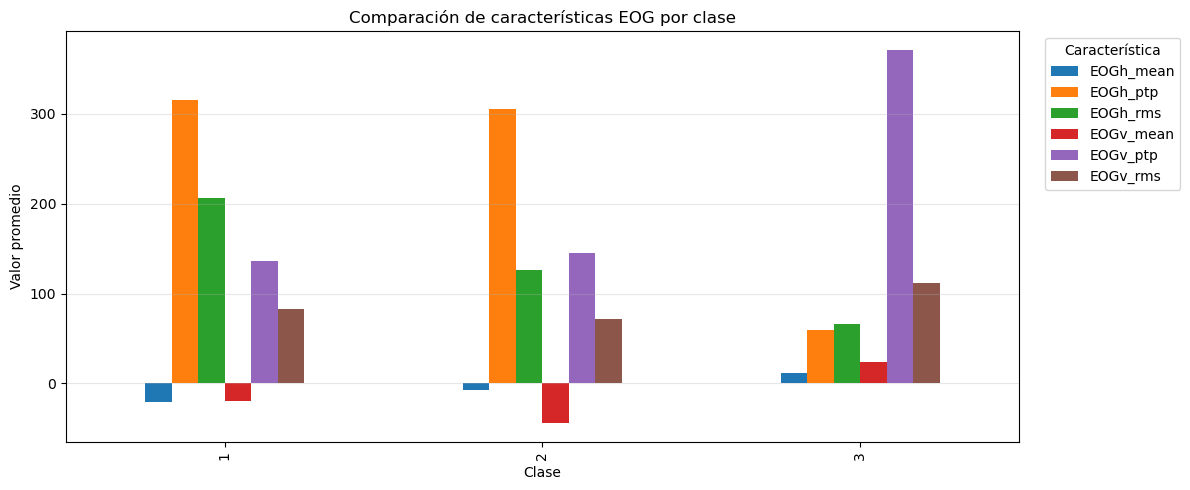

In [19]:
# Características seleccionadas para comparar las clases
FEATURES_TO_COMPARE = [
    "EOGh_mean",
    "EOGh_ptp",
    "EOGh_rms",
    "EOGv_mean",
    "EOGv_ptp",
    "EOGv_rms",
]

missing_features = [
    col for col in FEATURES_TO_COMPARE
    if col not in features_df.columns
]

if missing_features:
    raise ValueError(
        f"Estas características no existen en features_df: {missing_features}"
    )

# Valor promedio de cada característica por clase
summary = features_df.groupby("label")[FEATURES_TO_COMPARE].mean()

display(summary)

# Comparación gráfica
summary.plot(kind="bar", figsize=(12, 5))

plt.title("Comparación de características EOG por clase")
plt.xlabel("Clase")
plt.ylabel("Valor promedio")
plt.legend(title="Característica", bbox_to_anchor=(1.02, 1))
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Fin de la experiencia

La experiencia termina cuando se cuenta con:

- el `features_df` final;
- la cantidad de ventanas por clase;
- una comparación de las características entre clases.

A partir de estos resultados se realiza el análisis correspondiente en el reporte.
